In [5]:
%pip install matplotlib

   ---------------------------------------- 0.0/8.2 MB ? eta -:--:--
   -- ------------------------------------- 0.5/8.2 MB 3.4 MB/s eta 0:00:03
   ----- ---------------------------------- 1.0/8.2 MB 3.1 MB/s eta 0:00:03
   -------- ------------------------------- 1.8/8.2 MB 3.1 MB/s eta 0:00:03
   ------------ --------------------------- 2.6/8.2 MB 3.4 MB/s eta 0:00:02
   --------------- ------------------------ 3.1/8.2 MB 3.2 MB/s eta 0:00:02
   ------------------- -------------------- 3.9/8.2 MB 3.3 MB/s eta 0:00:02
   ---------------------- ----------------- 4.7/8.2 MB 3.4 MB/s eta 0:00:02
   -------------------------- ------------- 5.5/8.2 MB 3.4 MB/s eta 0:00:01
   ------------------------------- -------- 6.6/8.2 MB 3.6 MB/s eta 0:00:01
   ---------------------------------- ----- 7.1/8.2 MB 3.5 MB/s eta 0:00:01
   ---------------------------------------  8.1/8.2 MB 3.6 MB/s eta 0:00:01
   ---------------------------------------- 8.2/8.2 MB 3.5 MB/s eta 0:00:00
   ----------------


[notice] A new release of pip is available: 25.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [7]:
%pip install seaborn

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [8]:
# Imports y configuración
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Estilo general
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
plt.rcParams['font.family'] = 'DejaVu Sans'

print("✓ Librerías cargadas correctamente")
print(f"  pandas     {pd.__version__}")
print(f"  numpy      {np.__version__}")
print(f"  matplotlib {plt.matplotlib.__version__}")
print(f"  seaborn    {sns.__version__}")

✓ Librerías cargadas correctamente
  pandas     3.0.2
  numpy      2.4.4
  matplotlib 3.10.9
  seaborn    0.13.2


In [10]:
# Carga del dataset
df = pd.read_csv('../data/processed/df_master_final.csv')

print(f"Filas: {df.shape[0]}, Columnas: {df.shape[1]}")
print(f"\nColumnas: {df.columns.tolist()}")
print(f"\nPrimeras filas:")
df.head()

Filas: 112, Columnas: 14

Columnas: ['comuna', 'anio', 'total_delitos', 'victimas_viales', 'muertos_viales', 'extorsion', 'homicidio', 'hurto_a_persona', 'hurto_a_residencia', 'hurto_de_carro', 'hurto_de_moto', 'hurto_de_semoviente', 'bienestar_score', 'nivel_bienestar']

Primeras filas:


,comuna,anio,total_delitos,victimas_viales,muertos_viales,extorsion,homicidio,hurto_a_persona,hurto_a_residencia,hurto_de_carro,hurto_de_moto,hurto_de_semoviente,bienestar_score,nivel_bienestar
0,1.0,2015,243,583,5,6,8,95,52,6,76,0,0.810070,alto
1,1.0,2016,282,591,3,8,15,159,33,6,61,0,0.857138,alto
2,1.0,2017,358,463,4,6,12,167,103,4,66,0,0.860027,alto
3,1.0,2018,457,517,5,24,12,216,105,6,94,0,0.803345,alto
4,1.0,2019,541,591,4,14,21,303,82,11,110,0,0.796878,alto


In [11]:
# Tipos y nulos
print("Tipos de datos:")
print(df.dtypes)
print(f"\nValores nulos:")
print(df.isnull().sum())
print(f"\nEstadísticas generales:")
df.describe()

Tipos de datos:
comuna                 float64
anio                     int64
total_delitos            int64
victimas_viales          int64
muertos_viales           int64
extorsion                int64
homicidio                int64
hurto_a_persona          int64
hurto_a_residencia       int64
hurto_de_carro           int64
hurto_de_moto            int64
hurto_de_semoviente      int64
bienestar_score        float64
nivel_bienestar            str
dtype: object

Valores nulos:
comuna                 0
anio                   0
total_delitos          0
victimas_viales        0
muertos_viales         0
extorsion              0
homicidio              0
hurto_a_persona        0
hurto_a_residencia     0
hurto_de_carro         0
hurto_de_moto          0
hurto_de_semoviente    0
bienestar_score        0
nivel_bienestar        0
dtype: int64

Estadísticas generales:


,comuna,anio,total_delitos,victimas_viales,muertos_viales,extorsion,homicidio,hurto_a_persona,hurto_a_residencia,hurto_de_carro,hurto_de_moto,hurto_de_semoviente,bienestar_score
count,112.00000,112.000000,112.000000,112.000000,112.000000,112.000000,112.000000,112.000000,112.000000,112.000000,112.000000,112.000000,1.120000e+02
mean,8.50000,2018.000000,2365.660714,1595.062500,13.241071,28.196429,28.151786,1764.089286,213.946429,55.883929,275.276786,0.116071,6.938894e-18
std,4.63049,2.008989,2628.126605,1075.921807,12.281419,21.935959,21.694525,2393.757025,155.222528,38.700221,172.021066,0.373576,9.397117e-01
min,1.00000,2015.000000,222.000000,317.000000,1.000000,5.000000,2.000000,95.000000,33.000000,4.000000,39.000000,0.000000,-3.627141e+00
25%,4.75000,2016.000000,825.250000,866.500000,5.000000,15.750000,13.000000,379.750000,107.750000,24.000000,149.750000,0.000000,-2.567257e-01
50%,8.50000,2018.000000,1571.500000,1287.500000,9.500000,23.000000,23.000000,923.000000,156.500000,50.000000,242.500000,0.000000,2.708000e-01
75%,12.25000,2020.000000,2528.750000,2010.000000,16.250000,33.500000,32.250000,1917.250000,291.250000,79.000000,348.500000,0.000000,6.130424e-01
max,16.00000,2021.000000,15516.000000,5415.000000,63.000000,148.000000,108.000000,14195.000000,644.000000,155.000000,1004.000000,2.000000,9.382030e-01


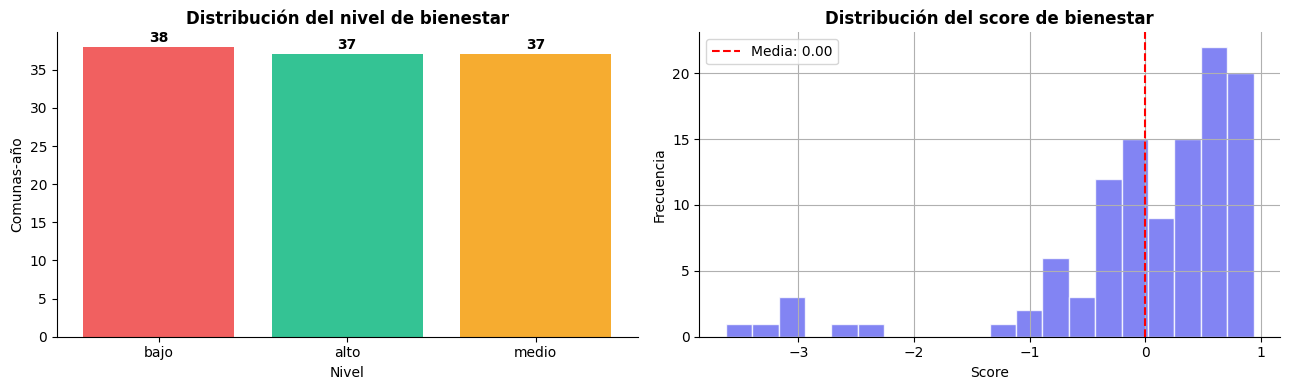

In [12]:
# Distribución de la variable objetivo
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

conteo = df['nivel_bienestar'].value_counts()
colores = {'alto': '#10b981', 'medio': '#f59e0b', 'bajo': '#ef4444'}

bars = axes[0].bar(conteo.index, conteo.values,
                   color=[colores[i] for i in conteo.index], alpha=0.85)
for bar, val in zip(bars, conteo.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                 str(val), ha='center', va='bottom', fontweight='bold')
axes[0].set_title('Distribución del nivel de bienestar', fontweight='bold')
axes[0].set_xlabel('Nivel'); axes[0].set_ylabel('Comunas-año')

df['bienestar_score'].hist(bins=20, ax=axes[1], color='#6366f1', alpha=0.8, edgecolor='white')
axes[1].axvline(df['bienestar_score'].mean(), color='red', linestyle='--',
                label=f"Media: {df['bienestar_score'].mean():.2f}")
axes[1].set_title('Distribución del score de bienestar', fontweight='bold')
axes[1].set_xlabel('Score'); axes[1].set_ylabel('Frecuencia')
axes[1].legend()

plt.tight_layout()
plt.savefig('../reports/figures/viz1_variable_objetivo.png', dpi=150, bbox_inches='tight')
plt.show()

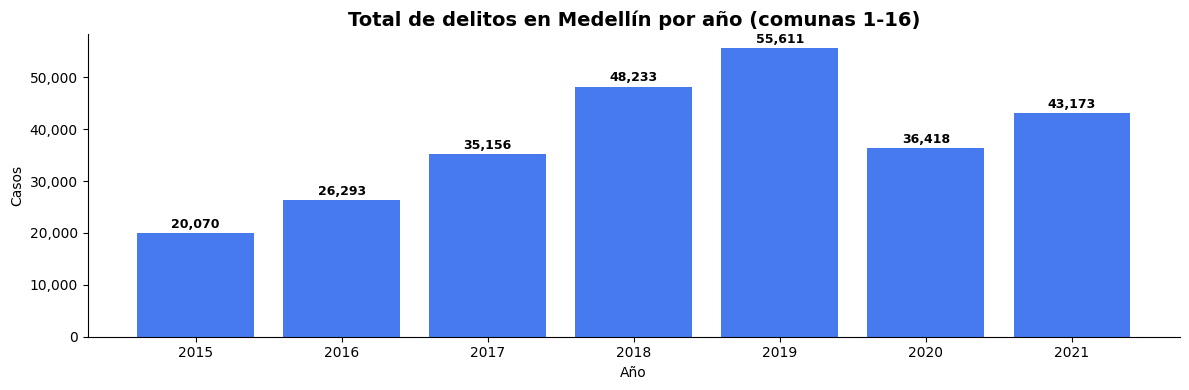

In [13]:
# Total de delitos por año
por_anio = df.groupby('anio')['total_delitos'].sum()

fig, ax = plt.subplots(figsize=(12, 4))
bars = ax.bar(por_anio.index.astype(str), por_anio.values, color='#2563eb', alpha=0.85)

for bar, val in zip(bars, por_anio.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 400,
            f'{val:,.0f}', ha='center', va='bottom', fontsize=9, fontweight='bold')

ax.set_title('Total de delitos en Medellín por año (comunas 1-16)', fontsize=14, fontweight='bold')
ax.set_xlabel('Año'); ax.set_ylabel('Casos')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
plt.tight_layout()
plt.savefig('../reports/figures/viz2_delitos_por_anio.png', dpi=150, bbox_inches='tight')
plt.show()

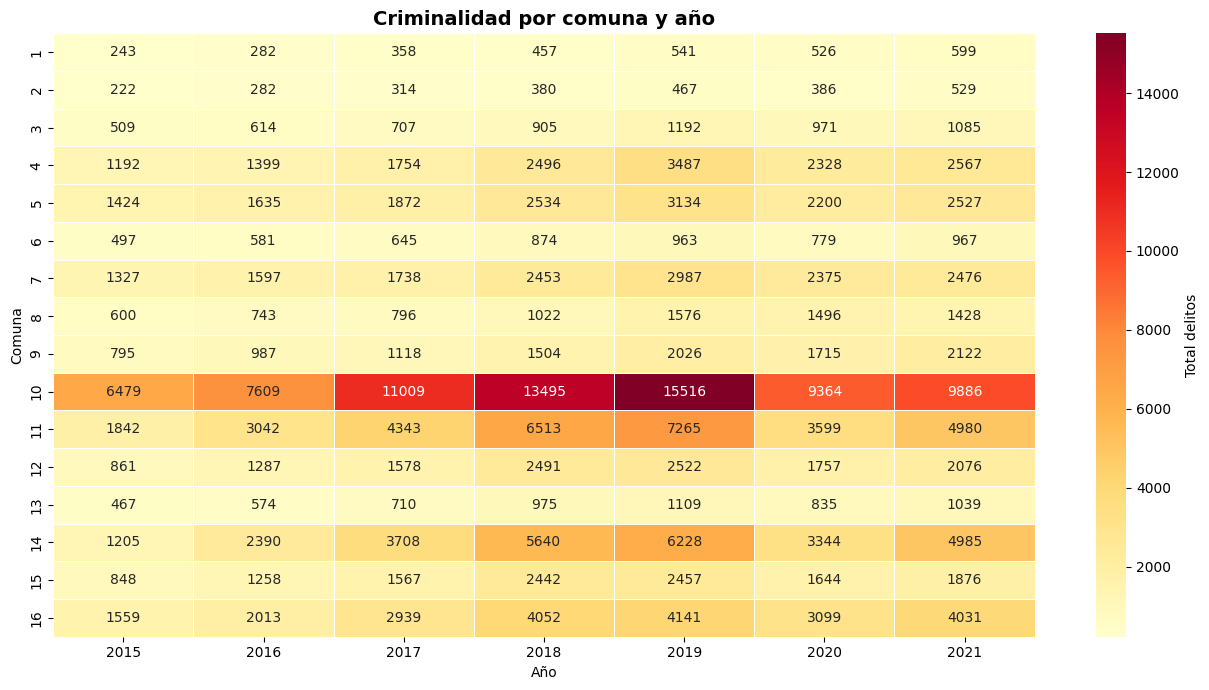

In [14]:
# Mapa de calor de criminalidad por comuna y año
pivot = df.pivot_table(index='comuna', columns='anio', values='total_delitos', aggfunc='sum')
pivot.index = pivot.index.astype(int)  # 10.0 → 10

fig, ax = plt.subplots(figsize=(13, 7))
sns.heatmap(pivot, cmap='YlOrRd', annot=True, fmt='.0f',
            linewidths=0.5, ax=ax, cbar_kws={'label': 'Total delitos'})
ax.set_title('Criminalidad por comuna y año', fontsize=14, fontweight='bold')
ax.set_xlabel('Año'); ax.set_ylabel('Comuna')
plt.tight_layout()
plt.savefig('../reports/figures/viz3_heatmap_criminalidad.png', dpi=150, bbox_inches='tight')
plt.show()

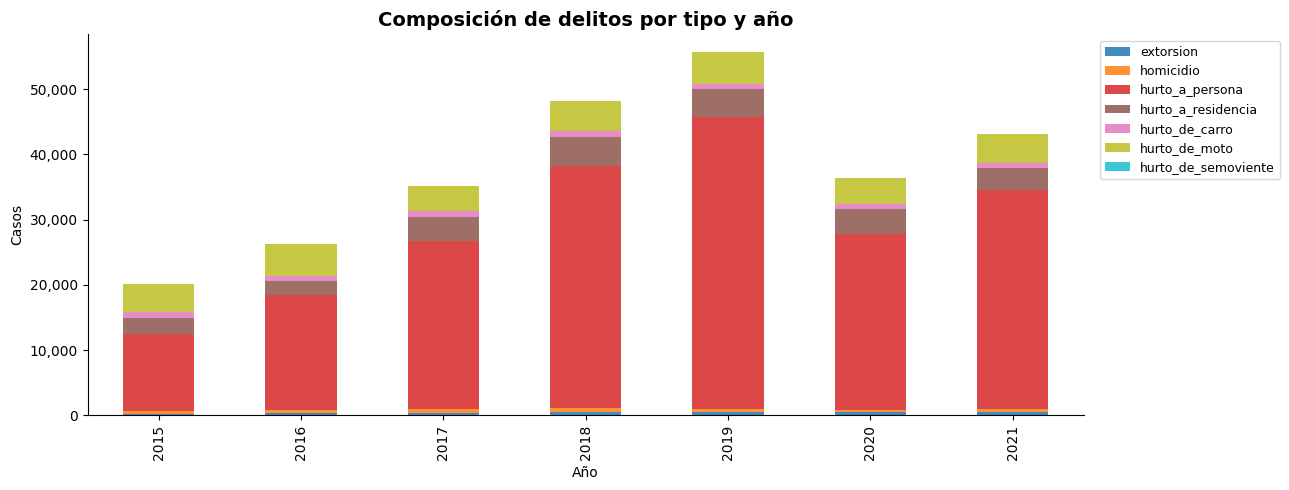

In [15]:
# Composición de delitos por tipo
cols_delito = ['extorsion', 'homicidio', 'hurto_a_persona',
               'hurto_a_residencia', 'hurto_de_carro', 'hurto_de_moto', 'hurto_de_semoviente']

por_tipo = df.groupby('anio')[cols_delito].sum()

fig, ax = plt.subplots(figsize=(13, 5))
por_tipo.plot(kind='bar', stacked=True, ax=ax, colormap='tab10', alpha=0.85)
ax.set_title('Composición de delitos por tipo y año', fontsize=14, fontweight='bold')
ax.set_xlabel('Año'); ax.set_ylabel('Casos')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
ax.legend(bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=9)
plt.tight_layout()
plt.savefig('../reports/figures/viz4_delitos_por_tipo.png', dpi=150, bbox_inches='tight')
plt.show()

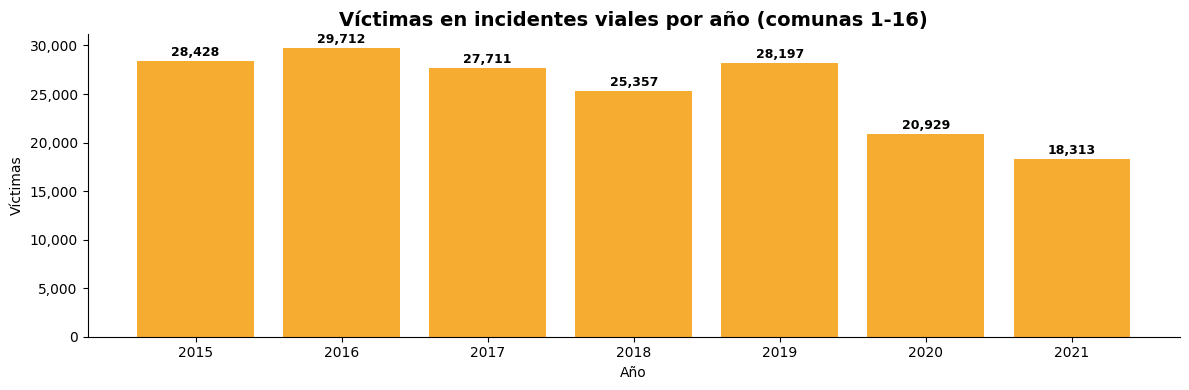

In [16]:
# Víctimas viales por año
por_anio_vial = df.groupby('anio')['victimas_viales'].sum()

fig, ax = plt.subplots(figsize=(12, 4))
bars = ax.bar(por_anio_vial.index.astype(str), por_anio_vial.values, color='#f59e0b', alpha=0.85)

for bar, val in zip(bars, por_anio_vial.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 200,
            f'{val:,.0f}', ha='center', va='bottom', fontsize=9, fontweight='bold')

ax.set_title('Víctimas en incidentes viales por año (comunas 1-16)', fontsize=14, fontweight='bold')
ax.set_xlabel('Año'); ax.set_ylabel('Víctimas')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
plt.tight_layout()
plt.savefig('../reports/figures/viz5_viales_por_anio.png', dpi=150, bbox_inches='tight')
plt.show()

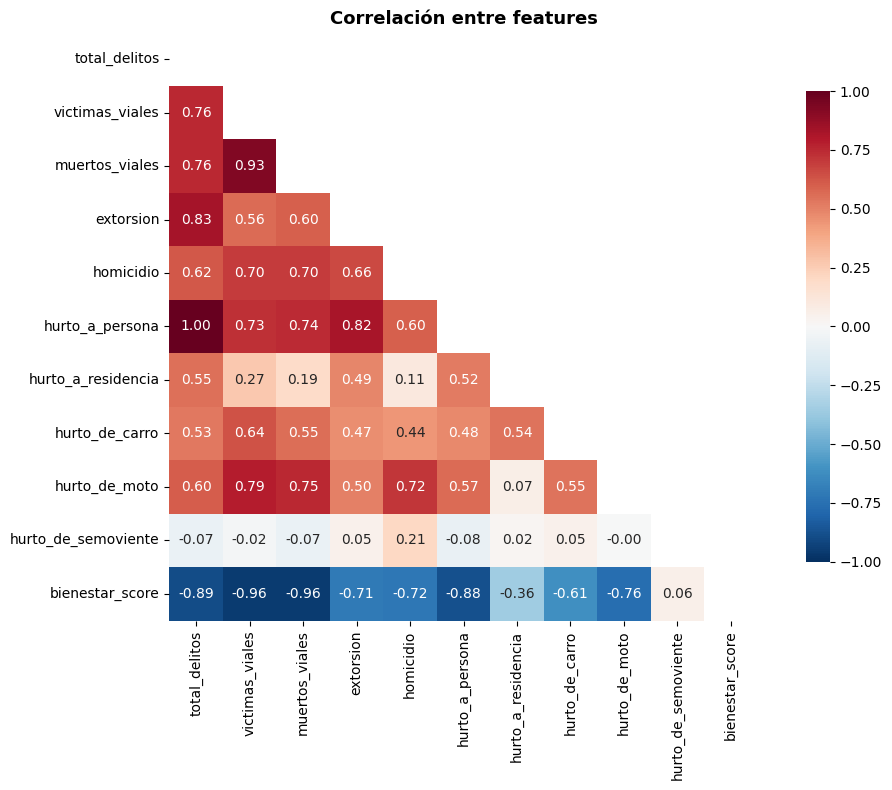

In [17]:
# Correlación entre features
features = ['total_delitos', 'victimas_viales', 'muertos_viales',
            'extorsion', 'homicidio', 'hurto_a_persona',
            'hurto_a_residencia', 'hurto_de_carro', 'hurto_de_moto',
            'hurto_de_semoviente', 'bienestar_score']

corr = df[features].corr()

fig, ax = plt.subplots(figsize=(11, 8))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            vmin=-1, vmax=1, ax=ax, square=True, cbar_kws={'shrink': 0.8})
ax.set_title('Correlación entre features', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../reports/figures/viz6_correlacion.png', dpi=150, bbox_inches='tight')
plt.show()

In [88]:
# Análisis de valores nulos y outliers
print("=== Valores nulos ===")
print(df.isnull().sum())

print("\n=== Outliers por feature (IQR) ===")
features = ['total_delitos', 'victimas_viales', 'muertos_viales',
            'extorsion', 'homicidio', 'hurto_a_persona',
            'hurto_a_residencia', 'hurto_de_carro', 'hurto_de_moto']

for col in features:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    outliers = df[(df[col] < Q1 - 1.5*IQR) | (df[col] > Q3 + 1.5*IQR)]
    print(f"  {col:25s}: {len(outliers)} outliers detectados")

print("\n=== Estrategia de manejo ===")
print("  - Valores nulos: imputación por mediana por comuna")
print("  - Outliers: se conservan (son datos reales de MEData, no errores)")
print("  - La comuna 10 genera outliers legítimos por su alta densidad comercial")

=== Valores nulos ===
comuna                 0
anio                   0
total_delitos          0
victimas_viales        0
muertos_viales         0
extorsion              0
homicidio              0
hurto_a_persona        0
hurto_a_residencia     0
hurto_de_carro         0
hurto_de_moto          0
hurto_de_semoviente    0
bienestar_score        0
nivel_bienestar        0
dtype: int64

=== Outliers por feature (IQR) ===
  total_delitos            : 11 outliers detectados
  victimas_viales          : 6 outliers detectados
  muertos_viales           : 7 outliers detectados
  extorsion                : 6 outliers detectados
  homicidio                : 8 outliers detectados
  hurto_a_persona          : 12 outliers detectados
  hurto_a_residencia       : 5 outliers detectados
  hurto_de_carro           : 0 outliers detectados
  hurto_de_moto            : 5 outliers detectados

=== Estrategia de manejo ===
  - Valores nulos: imputación por mediana por comuna
  - Outliers: se conservan (son dat

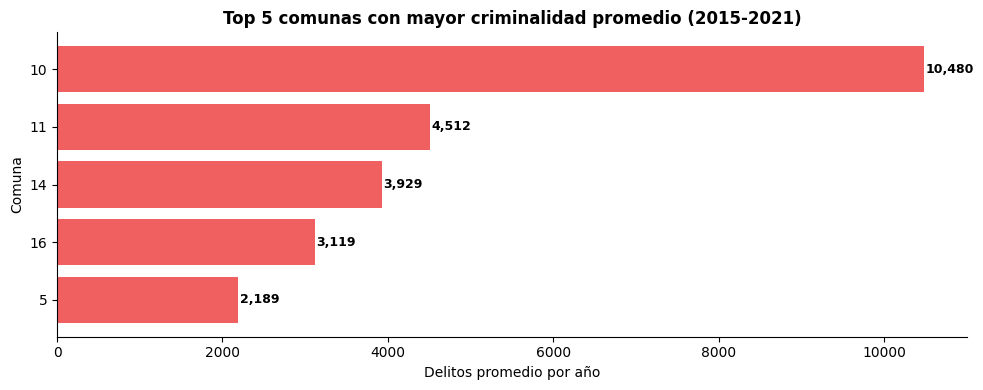

In [18]:
# Top 5 comunas con mayor criminalidad promedio
top_comunas = df.groupby('comuna')['total_delitos'].mean().sort_values(ascending=False).head(5)

fig, ax = plt.subplots(figsize=(10, 4))
bars = ax.barh(top_comunas.index.astype(int).astype(str), top_comunas.values, color='#ef4444', alpha=0.85)
for bar, val in zip(bars, top_comunas.values):
    ax.text(val + 20, bar.get_y() + bar.get_height()/2,
            f'{val:,.0f}', va='center', fontsize=9, fontweight='bold')
ax.set_title('Top 5 comunas con mayor criminalidad promedio (2015-2021)', fontweight='bold')
ax.set_xlabel('Delitos promedio por año'); ax.set_ylabel('Comuna')
ax.invert_yaxis()
plt.tight_layout()
plt.savefig('../reports/figures/viz7_top_comunas.png', dpi=150, bbox_inches='tight')
plt.show()

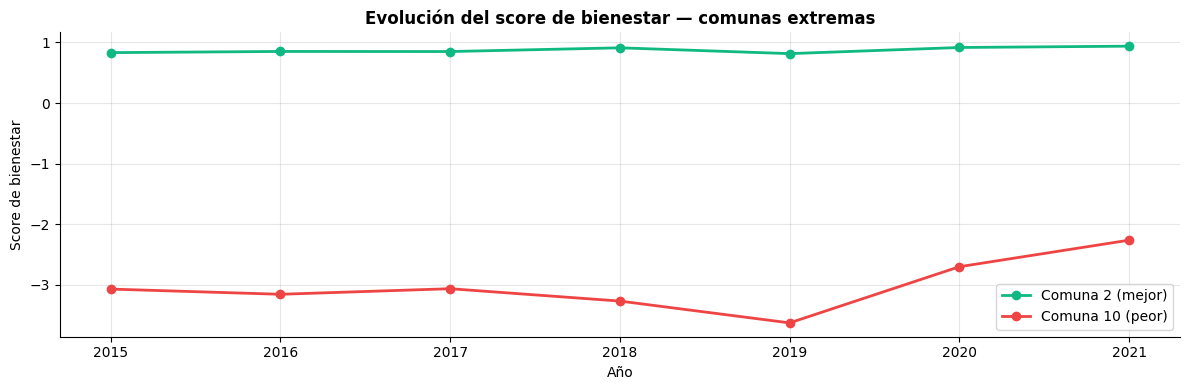

In [19]:
# Evolución del bienestar en comunas extremas
comuna_mejor = df.groupby('comuna')['bienestar_score'].mean().idxmax()
comuna_peor  = df.groupby('comuna')['bienestar_score'].mean().idxmin()

fig, ax = plt.subplots(figsize=(12, 4))
for comuna, color, label in [(comuna_mejor, '#10b981', f'Comuna {int(comuna_mejor)} (mejor)'),
                              (comuna_peor,  '#ef4444', f'Comuna {int(comuna_peor)} (peor)')]:
    datos = df[df['comuna'] == comuna].sort_values('anio')
    ax.plot(datos['anio'], datos['bienestar_score'], marker='o', color=color, label=label, linewidth=2)

ax.set_title('Evolución del score de bienestar — comunas extremas', fontweight='bold')
ax.set_xlabel('Año'); ax.set_ylabel('Score de bienestar')
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('../reports/figures/viz8_evolucion_bienestar.png', dpi=150, bbox_inches='tight')
plt.show()